In [1]:
import pandas as pd
import ast
from paretoset import paretoset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [2]:
name = 'multilabel1'

In [3]:
deepseek_df = pd.read_csv(f'../LLMs/local_llms/deepseek/results/deepseekR1_ZS_{name}.csv')
gemma_df = pd.read_csv(f'../LLMs/local_llms/gemma/results/gemma_ZS_{name}.csv')
llama_df = pd.read_csv(f'../LLMs/local_llms/llama/results/llama_ZS_{name}.csv')
openai_df = pd.read_csv(f'../LLMs/api_llms/openai/results/openai_ZS_{name}.csv')
gemini_df = pd.read_csv(f'../LLMs/api_llms/gemini/results/gemini_ZS_{name}.csv')

sklearn_df = pd.read_csv(f'../sklearn/results/results_sklearn_{name}.csv')
bert_df = pd.read_csv(f'../neural_nets/BERT_train/results/bert_{name}.csv')

lstm_df = pd.read_csv(f'../neural_nets/LSTM_FINAL/results/lstm_{name}.csv')

In [4]:
deepseek_df

,text,ENTREGA,OUTROS,PRODUTO,CONDICOES DE RECEBIMENTO,ANUNCIO,label_counts,response_time,vram_usage,ram_usage,total_time,response_text,ENTREGA pred,OUTROS pred,PRODUTO pred,CONDICOES DE RECEBIMENTO pred,ANUNCIO pred
0,"ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...",1,1,0,0,0,"{'ENTREGA': 0, 'OUTROS': 1, 'PRODUTO': 0, 'CON...",5.691375,2313,93.101562,3.657704,"Okay, let me try to figure out how to classify...",0,1,0,0,0
1,Recomendo!Os aparelhos da motorola são muito b...,0,0,1,0,0,"{'ENTREGA': 0, 'OUTROS': 0, 'PRODUTO': 1, 'CON...",6.666891,2313,93.031250,4.607866,"Okay, let me try to figure this out. The user ...",0,0,0,0,0
2,"Eu ameiii o produto, pena que veio com o espe...",0,0,1,1,0,"{'ENTREGA': 0, 'OUTROS': 0, 'PRODUTO': 0, 'CON...",6.219995,2319,92.984375,4.182087,"Okay, let me try to figure this out. The user ...",0,0,0,0,0
3,bom..............................................,0,0,1,0,0,"{'ENTREGA': 0, 'OUTROS': 1, 'PRODUTO': 0, 'CON...",5.229363,2313,93.050781,3.184147,"Okay, let me try to figure this out. The user ...",0,1,0,0,0
4,Quero saber quando chegará mais pois gostaria ...,0,1,0,0,0,{},0.000000,0,0.000000,0.000000,API Error: HTTPConnectionPool(host='localhost'...,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,Produto veio com peças totalmente inferiores a...,0,0,0,1,1,"{'ENTREGA': 0, 'OUTROS': 1, 'PRODUTO': 1, 'CON...",5.543229,2480,69.828125,3.485215,"Okay, let me try to figure this out. The user ...",0,1,0,0,0
962,Recebi Produto diferente do anunciado - com ap...,0,0,0,1,1,"{'ENTREGA': 0, 'OUTROS': 0, 'PRODUTO': 0, 'CON...",6.471951,2470,69.832031,4.434541,"Okay, let me try to figure this out. The user ...",0,0,0,0,1
963,No anúncio constava três refis. Foi entregue a...,0,0,0,1,1,"{'ENTREGA': 1, 'OUTROS': 0, 'PRODUTO': 0, 'CON...",6.782431,2470,68.878906,4.741056,"Okay, let me try to figure this out. The user ...",1,0,0,1,0
964,Comprei o produto na cor que está publicado no...,0,0,0,1,1,"{'ENTREGA': 0, 'OUTROS': 0, 'PRODUTO': 1, 'CON...",5.231913,2470,69.386719,3.154828,"Okay, let me try to figure this out. The user ...",0,0,0,0,0


In [5]:
size = len(deepseek_df)
size

966

In [6]:
labels = deepseek_df.columns[1:6]
print(labels)

Index(['ENTREGA', 'OUTROS', 'PRODUTO', 'CONDICOES DE RECEBIMENTO', 'ANUNCIO'], dtype='object')


In [7]:
def results_lstm(df):

    accuracy = df['test_acc'].mean()
    precision = df['test_prec'].mean()
    recall = df['test_rec'].mean()
    f1 = df['test_f1'].mean()
    mean_ram_usage = df['max_memory_usage_test'].mean()
    mean_vram_usage = df['max_vram_usage_test'].mean()
    mean_time = df['total_time_test'].mean()

    accuracy_std = df['test_acc'].std()
    precision_std = df['test_prec'].std()
    recall_std = df['test_rec'].std()
    f1_std = df['test_f1'].std()
    mean_ram_usage_std = df['max_memory_usage_test'].std()
    mean_vram_usage_std = df['max_vram_usage_test'].std()
    mean_time_std = df['total_time_test'].std()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time / size
    }

    results_std = {
        'accuracy_std': accuracy_std,
        'precision_std': precision_std,
        'recall_std': recall_std,
        'f1_score_std': f1_std,
        'mean_ram_usage_std': mean_ram_usage_std,
        'mean_vram_usage_std': mean_vram_usage_std,
        'mean_response_time_std': mean_time_std / size
    }

    return results, results_std

results_lstm_model = results_lstm(lstm_df)[0]

In [8]:
def results_llm(df):

    try:
        for label in labels:
            df[f"{label} pred"] = df.apply(lambda row: 1 if label in row['prediction_post_processed'] else 0, axis=1)
    except:
        pass

    y_true = df[labels].values
    y_pred = df[[f"{label} pred" for label in labels]].values

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    try:
        mean_ram_usage = df['ram_usage'].mean()
        mean_vram_usage = df['vram_usage'].mean()
    except:
        mean_ram_usage = 0
        mean_vram_usage = 0
    
    try:
        mean_time = df['response_time'].mean()
    except:
        mean_time = df['request_time'].mean()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time
    }

    print(results)

    return results

In [9]:
print("DeepSeek results:")
results_deepseek = results_llm(deepseek_df)
print("\n")
print("Gemma results:")
results_gemma = results_llm(gemma_df)
print("\n")
print("Llama results:")
results_llama = results_llm(llama_df)
print("\n")
print("OpenAI results:")
results_openai = results_llm(openai_df)
print("\n")
print("Gemini results:")
results_gemini = results_llm(gemini_df)
print("\n")

DeepSeek results:
{'accuracy': 0.016563146997929608, 'precision': np.float64(0.23138295727784314), 'recall': np.float64(0.29073891065944113), 'f1_score': np.float64(0.2505601791541547), 'mean_ram_usage': np.float64(74.43956230590062), 'mean_vram_usage': np.float64(2482.3985507246375), 'mean_response_time': np.float64(6.464776520896896)}


Gemma results:
{'accuracy': 0.06935817805383022, 'precision': np.float64(0.38700242334696117), 'recall': np.float64(0.4594793732515531), 'f1_score': np.float64(0.38833766642208556), 'mean_ram_usage': np.float64(105.23503008540372), 'mean_vram_usage': np.float64(5404.457556935818), 'mean_response_time': np.float64(2.4285199600223675)}


Llama results:
{'accuracy': 0.035196687370600416, 'precision': np.float64(0.2719754838600671), 'recall': np.float64(0.4456893665917182), 'f1_score': np.float64(0.20864319222710334), 'mean_ram_usage': np.float64(88.10453060300208), 'mean_vram_usage': np.float64(4644.770186335404), 'mean_response_time': np.float64(2.39483

c:\Users\Rafael\Desktop\Prog\TCC\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rafael\Desktop\Prog\TCC\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rafael\Desktop\Prog\TCC\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

In [10]:
def results_sklearn(df):
    
    grouped = df.groupby(['vectorizer', 'model', 'params'])

    df['average_f1'] = df.filter(like='f1_class_').mean(axis=1)
    df['average_precision'] = df.filter(like='precision_class_').mean(axis=1)
    df['average_recall'] = df.filter(like='recall_class_').mean(axis=1)
    
    mean_f1 = grouped['average_f1'].mean().reset_index()
    
    best_model = mean_f1.loc[mean_f1['average_f1'].idxmax()]
    
    best_config_df = df[(df['vectorizer'] == best_model['vectorizer']) &
                        (df['model'] == best_model['model']) &
                        (df['params'] == best_model['params'])]
    
    accuracy = best_config_df['accuracy'].mean()
    f1 = best_config_df['average_f1'].mean()
    precision = best_config_df['average_precision'].mean()
    recall = best_config_df['average_recall'].mean()
    mean_ram_usage = best_config_df['peak_memory_prediction'].mean()
    mean_vram_usage = 0
    pred_time = best_config_df['prediction_time'].mean()

    std_accuracy = best_config_df['accuracy'].std()
    std_f1 = best_config_df['average_f1'].std()
    std_precision = best_config_df['average_precision'].std()
    std_recall = best_config_df['average_recall'].std()
    std_ram_usage = best_config_df['peak_memory_prediction'].std()
    std_vram_usage = 0
    std_pred_time = best_config_df['prediction_time'].std()


    results = {
        'name': best_model['model'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': pred_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_mean_ram_usage': std_ram_usage,
        'std_mean_vram_usage': std_vram_usage,
        'std_mean_response_time': std_pred_time / size
    }
    

    return results, results_std

In [11]:
results_sklearn_model = results_sklearn(sklearn_df)[0]

In [12]:
def results_bert(df):

    df['average_test_f1'] = df['test_f1s'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_precisions'] = df['test_precisions'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_recalls'] = df['test_recalls'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )

    accuracy = df['test_acc'].mean()
    precision = df['average_test_precisions'].mean()
    recall = df['average_test_recalls'].mean()
    f1 = df['average_test_f1'].mean()
    mean_ram_usage = df['max_memory_usage_test'].mean()
    mean_vram_usage = df['max_vram_usage_test'].mean()
    mean_time = df['total_test_time'].mean()

    # now get standar deviation
    std_accuracy = df['test_acc'].std()
    std_precision = df['average_test_precisions'].std()
    std_recall = df['average_test_recalls'].std()
    std_f1 = df['average_test_f1'].std()
    std_ram_usage = df['max_memory_usage_test'].std()
    std_vram_usage = df['max_vram_usage_test'].std()
    std_time = df['total_test_time'].std()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_ram_usage': std_ram_usage,
        'std_vram_usage': std_vram_usage,
        'std_response_time': std_time / size
    }

    
    return results, results_std

results_bert_model = results_bert(bert_df)[0]
results_bert_model

{'accuracy': np.float64(0.777432712215321),
 'precision': np.float64(0.8749018408066828),
 'recall': np.float64(0.8758632538515755),
 'f1_score': np.float64(0.8742662766409897),
 'mean_ram_usage': np.float64(1262.1080729166667),
 'mean_vram_usage': np.float64(1705.302734375),
 'mean_response_time': np.float64(0.009065015942024277)}

Models on the Pareto Frontier:
                model      time        f1
5                BERT  0.009065  0.874266
6                LSTM  0.000869  0.562470
7  LogisticRegression  0.001979  0.832249


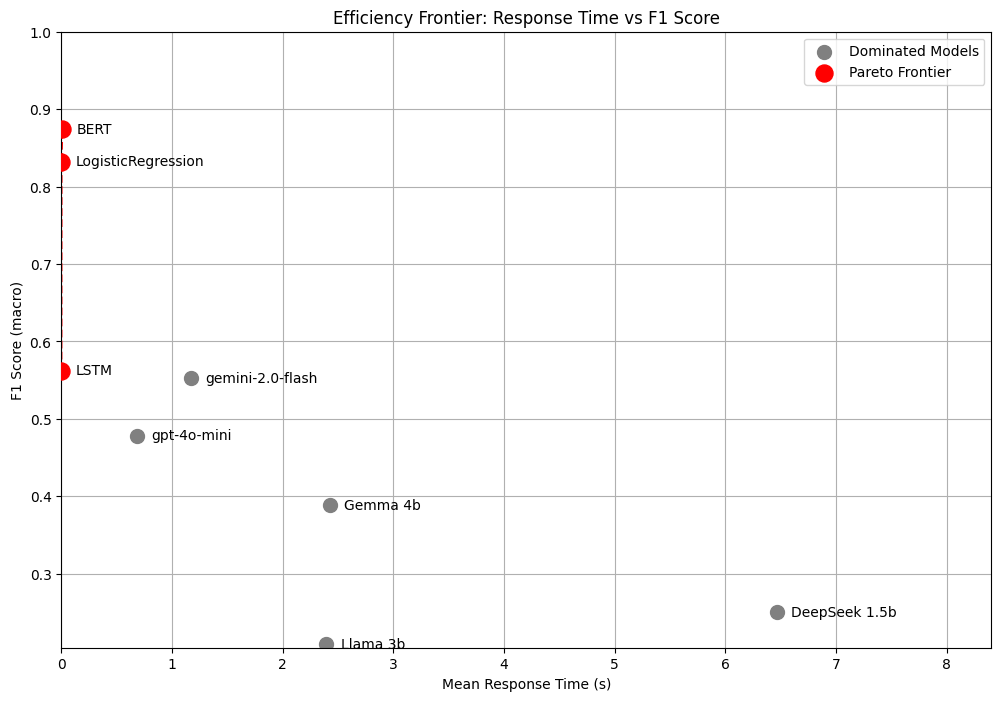

In [13]:
def plot_results(results):
    models = ['DeepSeek 1.5b', 'Gemma 4b', 'Llama 3b', 'gpt-4o-mini', 'gemini-2.0-flash', 'BERT', 'LSTM', results[-1]['name']]
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]

    df = pd.DataFrame({
        'model': models,
        'time': mean_response_times,
        'f1': f1_scores
    })

    is_on_frontier = paretoset(df[['time', 'f1']], sense=['min', 'max'])
    
    frontier_df = df[is_on_frontier]
    
    print("Models on the Pareto Frontier:")
    print(frontier_df)

    plt.figure(figsize=(12, 8))
    
    plt.scatter(df['time'], df['f1'], color='grey', s=100, label='Dominated Models')
    
    plt.scatter(frontier_df['time'], frontier_df['f1'], color='red', s=150, zorder=5, label='Pareto Frontier')
    
    frontier_df = frontier_df.sort_values(by='time')
    plt.plot(frontier_df['time'], frontier_df['f1'], 'r--')

    offset = (max(mean_response_times) * 0.02)
    for i, row in df.iterrows():
        plt.text(row['time'] + offset, row['f1'], row['model'], ha='left', va='center')

    xlim_max = max(mean_response_times)
    plt.xlim(left=0, right=xlim_max + xlim_max * 0.3)
    plt.ylim(bottom=min(f1_scores) * 0.98, top=1.0)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency Frontier: Response Time vs F1 Score')
    plt.legend()
    plt.grid(True)
    
    plt.show()

plot_results([results_deepseek, results_gemma, results_llama, results_openai, results_gemini, results_bert_model, results_lstm_model, results_sklearn_model])

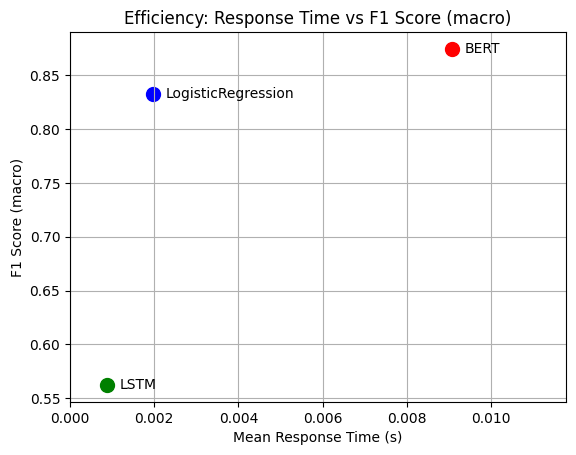

In [14]:
def plot_results(results):
    models = ['BERT', 'LSTM', results[-1]['name']]
    colors = ['red', 'green', 'blue']
    
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]
    
    offset = 0.0003
    
    for i in range(len(models)):
        plt.scatter(mean_response_times[i], f1_scores[i], color=colors[i], s=100)
        plt.text(mean_response_times[i] + offset, f1_scores[i], models[i], ha='left', va='center')
    
    xlim = max(mean_response_times)

    plt.xlim(left = 0, right = xlim + xlim * 0.3)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency: Response Time vs F1 Score (macro)')
    plt.grid(True)
    
    plt.show()

plot_results([results_bert_model, results_lstm_model, results_sklearn_model])

In [15]:
results_df = pd.DataFrame({
    'model': ['DeepSeek 1.5b', 'Gemma 4b', 'Llama 3b', 'gpt-4o-mini', 'gemini-2.0-flash', 'BERT', 'LSTM', results_sklearn_model['name']],
    'accuracy': [results_deepseek['accuracy'], results_gemma['accuracy'], results_llama['accuracy'], results_openai['accuracy'], results_gemini['accuracy'], results_bert_model['accuracy'], results_lstm_model['accuracy'], results_sklearn_model['accuracy']],
    'precision': [results_deepseek['precision'], results_gemma['precision'], results_llama['precision'], results_openai['precision'], results_gemini['precision'], results_bert_model['precision'], results_lstm_model['precision'], results_sklearn_model['precision']],
    'recall': [results_deepseek['recall'], results_gemma['recall'], results_llama['recall'], results_openai['recall'], results_gemini['recall'], results_bert_model['recall'], results_lstm_model['recall'], results_sklearn_model['recall']],
    'f1_score': [results_deepseek['f1_score'], results_gemma['f1_score'], results_llama['f1_score'], results_openai['f1_score'], results_gemini['f1_score'], results_bert_model['f1_score'], results_lstm_model['f1_score'], results_sklearn_model['f1_score']],
    'mean_ram_usage': [results_deepseek['mean_ram_usage'], results_gemma['mean_ram_usage'], results_llama['mean_ram_usage'], results_openai['mean_ram_usage'], results_gemini['mean_ram_usage'], results_bert_model['mean_ram_usage'], results_lstm_model['mean_ram_usage'], results_sklearn_model['mean_ram_usage']],
    'mean_vram_usage': [results_deepseek['mean_vram_usage'], results_gemma['mean_vram_usage'], results_llama['mean_vram_usage'], results_openai['mean_vram_usage'], results_gemini['mean_vram_usage'], results_bert_model['mean_vram_usage'], results_lstm_model['mean_vram_usage'], results_sklearn_model['mean_vram_usage']],
    'mean_response_time': [results_deepseek['mean_response_time'], results_gemma['mean_response_time'], results_llama['mean_response_time'], results_openai['mean_response_time'], results_gemini['mean_response_time'], results_bert_model['mean_response_time'], results_lstm_model['mean_response_time'], results_sklearn_model['mean_response_time']]
})

results_df.to_csv(f'results/results_{name}.csv', index=False)

In [16]:
results_bert_std = results_bert(bert_df)[1]
results_lstm_std = results_lstm(lstm_df)[1]
results_sklearn_std = results_sklearn(sklearn_df)[1]

results_std_df = pd.DataFrame({
    'model': ['BERT', 'LSTM', results_sklearn_model['name']],
    'accuracy_std': [results_bert_std['std_accuracy'], results_lstm_std['accuracy_std'], results_sklearn_std['std_accuracy']],
    'precision_std': [results_bert_std['std_precision'], results_lstm_std['precision_std'], results_sklearn_std['std_precision']],
    'recall_std': [results_bert_std['std_recall'], results_lstm_std['recall_std'], results_sklearn_std['std_recall']],
    'f1_score_std': [results_bert_std['std_f1_score'], results_lstm_std['f1_score_std'], results_sklearn_std['std_f1_score']],
    'mean_ram_usage_std': [results_bert_std['std_ram_usage'], results_lstm_std['mean_ram_usage_std'], results_sklearn_std['std_mean_ram_usage']],
    'mean_vram_usage_std': [results_bert_std['std_vram_usage'], results_lstm_std['mean_vram_usage_std'], results_sklearn_std['std_mean_vram_usage']],
    'mean_response_time_std': [results_bert_std['std_response_time'], results_lstm_std['mean_response_time_std'], results_sklearn_std['std_mean_response_time']]
})

results_std_df.to_csv(f'results/results_std_{name}.csv', index=False)